# BrainInsight AI
# Notebook 08: Severity Analysis

## Objectives
Estimate a **research/demo severity score** from tumor measurements extracted during segmentation.

> **Disclaimer:** This severity score is designed for educational and research purposes only. It is **not** a medical diagnosis.


In [1]:
import matplotlib.pyplot as plt

# Example measurements (replace with values from Notebook 07)
measurements = {
    "Tumor Area (%)": 66.19,
    "Texture": 46.45,
    "Circularity": 0.89,
    "Brightness": 98.44,
    "Edge Irregularity": 0.98
}


## Severity Calculation

In [2]:
def normalize(value, max_value):
    value = max(0, min(value, max_value))
    return value / max_value

def calculate_severity(measurements):
    area = normalize(measurements["Tumor Area (%)"], 100)
    texture = normalize(measurements["Texture"], 100)
    circularity = 1 - normalize(measurements["Circularity"], 1)
    brightness = normalize(measurements["Brightness"], 255)
    edge = normalize(measurements["Edge Irregularity"], 1)

    score = (
        0.35 * area +
        0.20 * texture +
        0.15 * circularity +
        0.15 * brightness +
        0.15 * edge
    ) * 100

    if score < 35:
        risk = "Low Risk"
    elif score < 70:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    return round(score, 2), risk

severity_score, risk_level = calculate_severity(measurements)

print("Severity Score :", severity_score)
print("Risk Level     :", risk_level)


Severity Score : 54.6
Risk Level     : Medium Risk


## Severity Breakdown

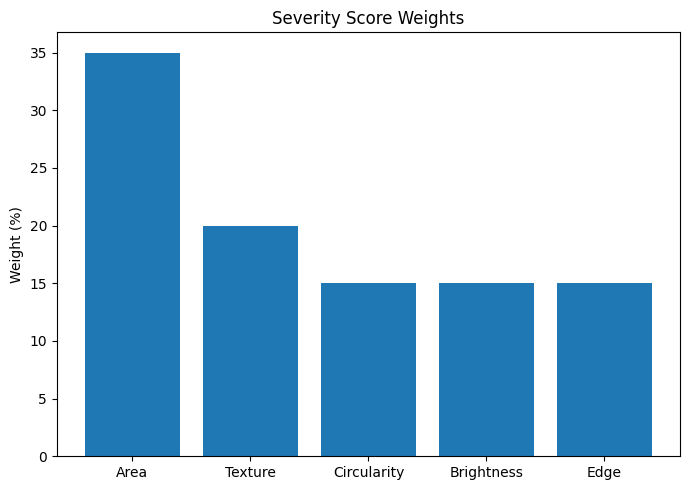

In [3]:
labels = [
    "Area",
    "Texture",
    "Circularity",
    "Brightness",
    "Edge"
]

weights = [35, 20, 15, 15, 15]

plt.figure(figsize=(7,5))
plt.bar(labels, weights)
plt.title("Severity Score Weights")
plt.ylabel("Weight (%)")
plt.tight_layout()
plt.show()


## Severity Summary

In [4]:
print("="*45)
print("BrainInsight AI - Severity Report")
print("="*45)

for k, v in measurements.items():
    print(f"{k:<22}: {v}")

print("-"*45)
print(f"Severity Score : {severity_score}")
print(f"Risk Level     : {risk_level}")
print("-"*45)
print("Disclaimer:")
print("This severity score is for educational and")
print("research purposes only and should not be")
print("used as a substitute for professional")
print("medical diagnosis.")


BrainInsight AI - Severity Report
Tumor Area (%)        : 66.19
Texture               : 46.45
Circularity           : 0.89
Brightness            : 98.44
Edge Irregularity     : 0.98
---------------------------------------------
Severity Score : 54.6
Risk Level     : Medium Risk
---------------------------------------------
Disclaimer:
This severity score is for educational and
research purposes only and should not be
used as a substitute for professional
medical diagnosis.


## Conclusion

A weighted severity score was computed using handcrafted image measurements. This score provides an interpretable estimate of tumor severity for demonstration purposes and will be included in the final PDF report.


## Interview Notes

- Why create a severity score?
- Why normalize measurements before combining them?
- Why assign different weights?
- Why classify into Low, Medium and High Risk?
- Why include a medical disclaimer?
